# 05 指标计算模块 (core.metrics)

提供分类、回归、特征评估、稳定性、金融风控等场景的评估指标。

**指标分类：**
- 分类指标: ks, auc, gini, accuracy, precision, recall, f1, ks_bucket, confusion_matrix, classification_report
- 特征评估: iv, iv_table, chi2_test, cramers_v, feature_importance
- 稳定性: psi, psi_table, psi_rating, csi, csi_table, batch_psi
- 金融风控: lift, lift_at, lift_table, lift_curve, badrate, badrate_by_group
- 回归指标: mse, mae, rmse, r2

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import os, sys
sys.path.append('../')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit import init_setting
from hscredit.core.metrics import (
    ks, auc, gini,
    accuracy, precision, recall, f1,
    confusion_matrix, classification_report,
    ks_bucket, roc_curve,
    iv, iv_table,
    chi2_test, cramers_v, feature_importance,
    psi, psi_table, psi_rating,
    csi, csi_table,
    lift, lift_at, lift_table, lift_curve,
    badrate, badrate_by_group, badrate_by_score_bin,
    mse, mae, rmse, r2,
)
from hscredit.core.models import LogisticRegression

init_setting()

df = pd.read_excel('hscredit_yyp.xlsx')
df['target'] = (df['MOB1'] > 3).astype(int)

# 预测概率：归一化中智小牛分C3
y_true = df['target'].values
y_prob = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median()).values
y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

# 二值预测
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

print(f"样本数: {len(df):,}")
print(f"坏样本率: {y_true.mean():.2%}")

样本数: 970
坏样本率: 16.70%


## 1. 分类指标

In [3]:
# KS / AUC / Gini
print("=== 基础分类指标 ===")
print(f"KS:  {ks(y_true, y_prob):.4f}")
print(f"AUC: {auc(y_true, y_prob):.4f}")
print(f"Gini: {gini(y_true, y_prob):.4f}")

# ROC曲线数据
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
print(f"\nROC曲线点数: {len(fpr)}")

=== 基础分类指标 ===
KS:  0.1006
AUC: 0.4495
Gini: -0.1010

ROC曲线点数: 135


In [4]:
# Accuracy / Precision / Recall / F1（基于阈值预测）
print("=== 二分类评估指标 ===")
print(f"Accuracy:  {accuracy(y_true, y_pred):.4f}")
print(f"Precision: {precision(y_true, y_pred):.4f}")
print(f"Recall:    {recall(y_true, y_pred):.4f}")
print(f"F1:        {f1(y_true, y_pred):.4f}")

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
print("\n混淆矩阵:")
print(cm)

# 分类报告
print("\n分类报告:")
print(classification_report(y_true, y_pred, target_names=['好样本', '坏样本']))

=== 二分类评估指标 ===
Accuracy:  0.7278
Precision: 0.0952
Recall:    0.0741
F1:        0.0833

混淆矩阵:
[[694 114]
 [150  12]]

分类报告:
              precision    recall  f1-score   support

         好样本       0.82      0.86      0.84       808
         坏样本       0.10      0.07      0.08       162

    accuracy                           0.73       970
   macro avg       0.46      0.47      0.46       970
weighted avg       0.70      0.73      0.71       970



In [5]:
ks_df = ks_bucket(y_true, y_prob, max_n_bins=10)

## 2. 特征评估指标

In [6]:
# IV计算（批量）
features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3']
iv_results = []
for feat_name in features:
    feat_values = df[feat_name].fillna(df[feat_name].median())
    iv_val = iv(y_true, feat_values, max_n_bins=10)
    iv_results.append({'特征': feat_name, 'IV': iv_val})

iv_results_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
print("=== 特征IV值 ===")
display(iv_results_df)

=== 特征IV值 ===


,特征,IV
4,占信V3,0.1695
3,青云24,0.0834
0,中智小牛分C3,0.0479
1,珊瑚92,0.0224
2,极光欺诈分6v1,0.0160


In [7]:
# IV详细表
iv_detail = iv_table(y_true, df['中智小牛分C3'].fillna(df['中智小牛分C3'].median()), max_n_bins=10)
print("=== IV分箱详情表 ===")
display(iv_detail)

=== IV分箱详情表 ===


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"[-inf, 540.45)",49,37,12,0.0505,0.0458,0.0741,0.2449,0.4810,0.0136,0.0479,1.4664,0.0248,1.4664,0.0248,37,12,0.0283
1,1,"[540.45, 584.70)",48,38,10,0.0495,0.0470,0.0617,0.2083,0.2720,0.0040,0.0479,1.2474,0.0129,1.3580,0.0398,75,22,0.0430
2,2,"[584.70, 684.10)",776,646,130,0.8000,0.7995,0.8025,0.1675,0.0037,0.0000,0.0479,1.0031,0.0123,1.0425,0.3827,721,152,0.0459
3,3,"[684.10, 727.55)",48,42,6,0.0495,0.0520,0.0370,0.1250,-0.3389,0.0051,0.0479,0.7485,-0.0131,1.0272,0.5112,763,158,0.0310
4,4,"[727.55, +inf)",49,45,4,0.0505,0.0557,0.0247,0.0816,-0.8134,0.0252,0.0479,0.4888,-0.0272,1.0000,0.0000,808,162,0.0000


In [8]:
# 卡方检验和Cramers V
feat_vals = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median())
chi2_result = chi2_test(feat_vals, y_true)
cramers = cramers_v(feat_vals, y_true)
print(f"卡方检验: chi2={chi2_result[0]:.4f}, p-value={chi2_result[1]:.4f}")
print(f"Cramers V: {cramers:.4f}")

卡方检验: chi2=5.5502, p-value=0.1357
Cramers V: 0.0756


In [9]:
# 特征重要性
X_feat = df[features].fillna(df[features].median())
y_feat = y_true
importance = feature_importance(X_feat, y_feat)
print("=== 特征重要性 ===")
display(importance.sort_values(ascending=False))

=== 特征重要性 ===


占信V3       0.3323
青云24       0.2951
极光欺诈分6v1   0.1826
中智小牛分C3    0.1459
珊瑚92       0.0441
dtype: float64

## 3. 稳定性指标 (PSI/CSI)

In [10]:
# 模拟训练集/测试集PSI
np.random.seed(42)
score_train = np.random.normal(650, 80, 500)
score_test = np.random.normal(640, 85, 300)  # 模拟分布偏移

# PSI计算
psi_val = psi(score_train, score_test, max_n_bins=10)
print(f"PSI: {psi_val:.4f}")

# PSI详细表
psi_detail = psi_table(score_train, score_test, max_n_bins=10)
print("\n=== PSI分箱详情 ===")
display(psi_detail)

PSI: 0.0188

=== PSI分箱详情 ===


,分箱,期望样本数,实际样本数,期望占比,实际占比,PSI贡献
0,"[-inf, 602.0288)",139,101,0.2780,0.3367,0.0112
1,"[602.0288, 666.2087)",150,90,0.3000,0.3000,0.0000
2,"[666.2087, 687.8544)",52,28,0.1040,0.0933,0.0012
3,"[687.8544, 746.1337)",105,55,0.2100,0.1833,0.0036
4,"[746.1337, +inf)",54,26,0.1080,0.0867,0.0047


In [11]:
# PSI评级
psi_rating_result = psi_rating(psi_val)
print(f"PSI评级: {psi_rating_result}")

# CSI计算（Conditional PSI，条件PSI）
csi_val = csi(score_train, score_test, max_n_bins=10)
print(f"CSI: {csi_val:.4f}")

# CSI分箱表
csi_detail = csi_table(score_train, score_test, max_n_bins=10)
print("\n=== CSI分箱详情 ===")
display(csi_detail)

PSI评级: 没有显著变化 (PSI < 0.1)
CSI: 0.0451

=== CSI分箱详情 ===


,分箱,期望样本数,实际样本数,期望占比,实际占比,CSI贡献
0,"[-inf, 625.6522)",188,132,0.3760,0.4400,0.0101
1,"[625.6522, 687.8544)",153,87,0.3060,0.2900,0.0009
2,"[687.8544, +inf)",159,81,0.3180,0.2700,0.0079


## 4. 金融风控指标

In [12]:
# Lift指标
print("=== Lift指标 ===")
for ratio in [0.01, 0.03, 0.05, 0.10]:
    lift_val = lift_at(y_true, y_prob, ratios=ratio)
    print(f"Lift@{ratio*100:.0f}%: {lift_val:.2f}")

# lift_table
lift_t = lift_table(y_true, y_prob, max_n_bins=10)
print("\n=== Lift分箱表 ===")
display(lift_t)

=== Lift指标 ===
Lift@1%: 0.00
Lift@3%: 0.41
Lift@5%: 0.37
Lift@10%: 0.62

=== Lift分箱表 ===


,分箱,最小概率,最大概率,样本数,好样本数,坏样本数,坏样本率,样本占比,Lift值,坏账改善,累积Lift值,累积坏账改善
0,1,0.0000,0.1969,49,37,12,0.2449,0.0505,1.4664,0.0248,1.4664,0.0248
1,2,0.1995,0.3057,48,38,10,0.2083,0.0495,1.2474,0.0129,1.3580,0.0398
2,3,0.3135,0.4275,721,596,125,0.1734,0.7433,1.0381,0.1103,1.0760,0.4091
3,4,0.4352,0.6813,103,92,11,0.1068,0.1062,0.6395,-0.0428,1.0272,0.5112
4,5,0.6839,1.0000,49,45,4,0.0816,0.0505,0.4888,-0.0272,1.0000,0.0000


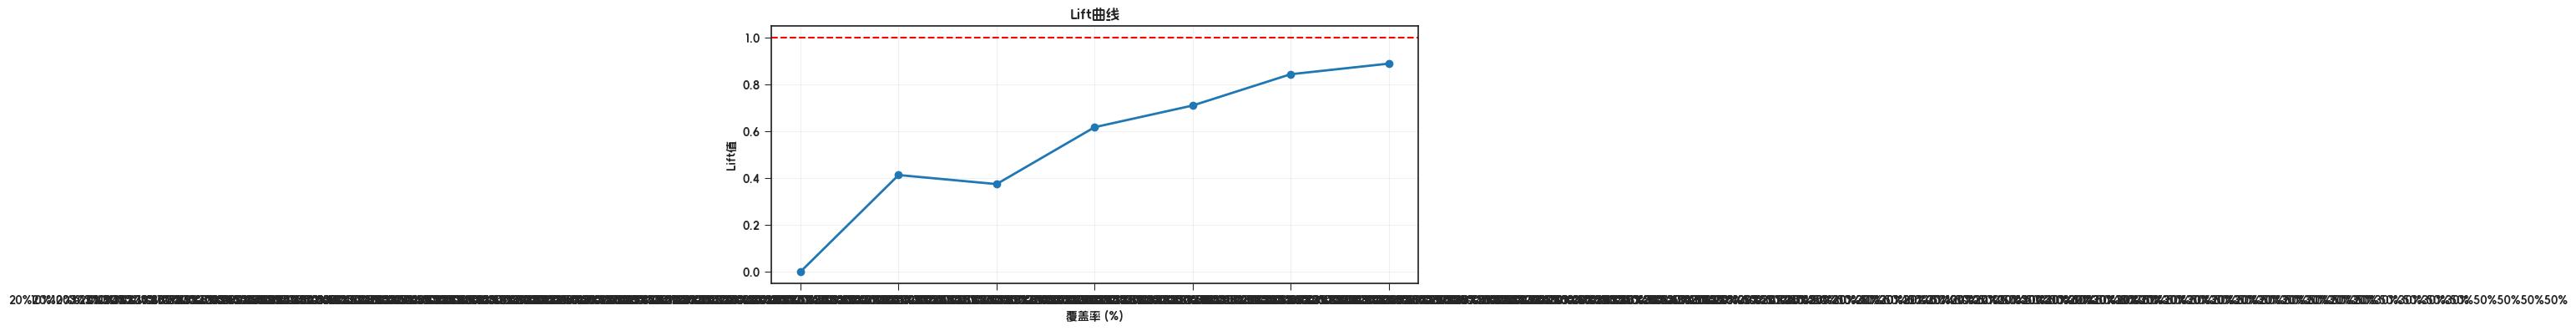

In [13]:
# Lift曲线
lift_curve_df = lift_curve(y_true, y_prob)
plt.figure(figsize=(10, 4))
plt.plot(lift_curve_df['覆盖率'] * 100, lift_curve_df['Lift值'], 'o-', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel('覆盖率 (%)')
plt.ylabel('Lift值')
plt.title('Lift曲线')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 坏样本率指标
feat_for_br = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median())

# 按特征分箱的坏样本率
br_by_bin = badrate_by_score_bin(y_true, feat_for_br, max_n_bins=5)
print("=== 特征分箱坏样本率 ===")
display(br_by_bin)

## 5. 回归指标

In [15]:
# 模拟回归场景
y_true_reg = np.array([3.2, 4.5, 2.8, 5.1, 3.9, 4.2, 2.5, 5.5, 3.0, 4.8])
y_pred_reg = np.array([3.0, 4.3, 3.0, 5.0, 4.1, 4.0, 2.7, 5.3, 3.2, 4.6])

print("=== 回归指标 ===")
print(f"MSE:  {mse(y_true_reg, y_pred_reg):.4f}")
print(f"MAE:  {mae(y_true_reg, y_pred_reg):.4f}")
print(f"RMSE: {rmse(y_true_reg, y_pred_reg):.4f}")
print(f"R2:   {r2(y_true_reg, y_pred_reg):.4f}")

=== 回归指标 ===
MSE:  0.0370
MAE:  0.1900
RMSE: 0.1924
R2:   0.9619


## 6. 指标汇总对比

=== 特征IV值排序 ===


,特征,IV
4,占信V3,0.1695
3,青云24,0.0834
0,中智小牛分C3,0.0479
1,珊瑚92,0.0224
2,极光欺诈分6v1,0.0160


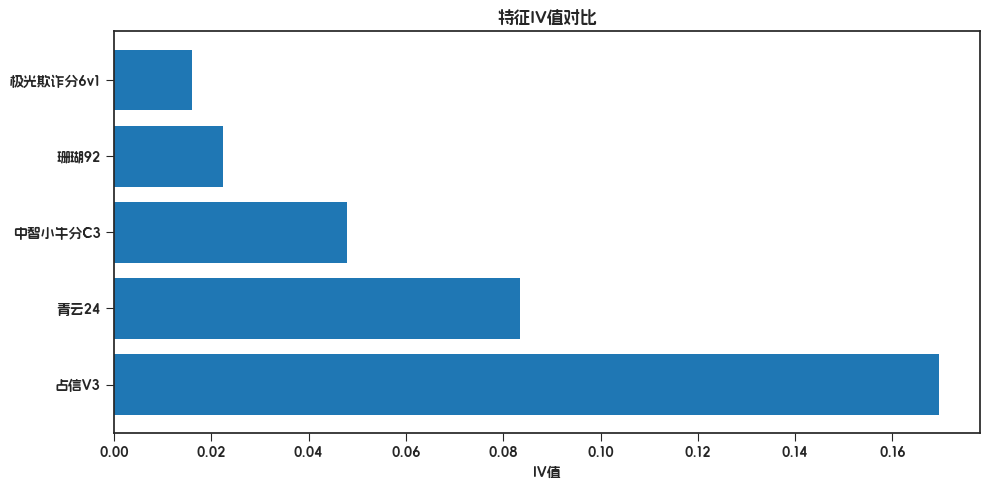

In [16]:
# 批量IV对比
print("=== 特征IV值排序 ===")
display(iv_results_df)

plt.figure(figsize=(10, 5))
plt.barh(iv_results_df['特征'], iv_results_df['IV'])
plt.xlabel('IV值')
plt.title('特征IV值对比')
plt.tight_layout()
plt.show()